# Scenario 1 — Synthetic Benchmark Problems
Chạy local (không cần Google Colab / Google Drive).  
Đặt file `Scenario_1.csv` cùng thư mục với notebook này rồi chạy từng cell.

In [1]:
# ── Cài thư viện nếu chưa có ──────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pandas', 'numpy', 'matplotlib', 'scipy', 'openpyxl',
                '--quiet'], check=False)

CompletedProcess(args=['c:\\Users\\ACER\\anaconda3\\envs\\ea_project\\python.exe', '-m', 'pip', 'install', 'pandas', 'numpy', 'matplotlib', 'scipy', 'openpyxl', '--quiet'], returncode=0)

In [ ]:
import os
import statistics

import numpy  as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

# ── Cấu hình ──────────────────────────────────────────────────
experiment_name             = 'Scenario_1'
file_name                   = 'results\Scenario_1_Novel_Final.csv' #experiment_name + '.csv'   # đặt cùng thư mục notebook
separator                   = ';'
delta_quantization          = 100
level_significance          = 0.01
efficiency_percentile_reference = 0.75

# ── Tạo thư mục output ────────────────────────────────────────
for folder in ['Figures/' + experiment_name,
               'LaTeX/'   + experiment_name,
               'XLSX Files/' + experiment_name]:
    os.makedirs(folder, exist_ok=True)

print('Thư mục output đã sẵn sàng.')

Thư mục output đã sẵn sàng.


In [3]:
# ── Đọc CSV ───────────────────────────────────────────────────
fileCSV = pd.read_csv(file_name, sep=separator)
print(f'Đọc xong: {len(fileCSV):,} dòng, {fileCSV["problem"].nunique()} problems, '
      f'{fileCSV["solver_sigma"].nunique()} solvers')
fileCSV.head(3)

Đọc xong: 1,857,693 dòng, 24 problems, 9 solvers


,iterations,evals,births,elapsed,all_size,firsts_size,lasts_size,geno_uni,sol_uni,fit_uni,best_fitness,seed,problem,solver_sigma,objective,best→fitness
0,1,12,12,0.0065,12,1,12,1.0,1.0,1.0,0.736117,7,ea.p.s.sphere-20,cmaEs,minimize,0.736117
1,2,24,24,0.0085,12,1,12,1.0,1.0,1.0,0.927360,7,ea.p.s.sphere-20,cmaEs,minimize,0.927360
2,3,36,36,0.0095,12,1,12,1.0,1.0,1.0,1.138824,7,ea.p.s.sphere-20,cmaEs,minimize,1.138824


In [4]:
# ── Tiền xử lý cột ────────────────────────────────────────────
fileCSV['solver'] = fileCSV['solver_sigma'].str.split('-').str[0]
fileCSV['sigma']  = fileCSV['solver_sigma'].str.split('-').str[1]
fileCSV['sigma']  = np.where(fileCSV['sigma'].isna(),
                             fileCSV['solver'],
                             fileCSV['sigma'])

fileCSV['solver_sigma_seed'] = (fileCSV['solver_sigma']
                                + '_seed:'
                                + fileCSV['seed'].astype(str))

# Đảm bảo có cột 'objective'
if 'objective' not in fileCSV.columns:
    fileCSV['objective'] = 'minimize'

# Đổi tên cột best→fitness → best_fitness
best_col = [c for c in fileCSV.columns if 'best' in c and 'fitness' in c][0]
fileCSV.rename(columns={best_col: 'best_fitness'}, inplace=True)

fileCSV['evals_quantized'] = fileCSV['evals'].astype(int) // delta_quantization

# Trích số chiều p từ tên problem (ví dụ: ea.p.s.ackley-100 → 100)
fileCSV['genotype_size'] = (fileCSV['problem']
                            .str.extract(r'-(\d+)(?:-|$)')
                            .astype(float)
                            .astype('Int64'))

united_CSV = fileCSV.copy()

# ── Danh sách unique ──────────────────────────────────────────
problems            = sorted(united_CSV['problem'].unique().tolist())
solvers             = sorted(united_CSV['solver'].unique().tolist())
sigmas              = sorted(united_CSV['sigma'].unique().tolist())
solvers_sigmas      = sorted(united_CSV['solver_sigma'].unique().tolist())
seeds               = sorted(united_CSV['seed'].unique().tolist())
solvers_sigmas_seeds= sorted(united_CSV['solver_sigma_seed'].unique().tolist())

print(f'problems ({len(problems)}):', problems[:4], '...')
print(f'solvers  ({len(solvers)}):', solvers)
print(f'sigmas   ({len(sigmas)}):', sigmas)
print(f'seeds    ({len(seeds)}):', seeds[:5], '...' if len(seeds)>5 else '')

problems (24): ['ea.p.s.ackley-100', 'ea.p.s.ackley-20', 'ea.p.s.ackley-200', 'ea.p.s.ackley-500'] ...
solvers  (5): ['cmaEs', 'differentialEvolution', 'es', 'ga', 'pso']
sigmas   (6): ['0.02', '0.25', '0.5', 'cmaEs', 'differentialEvolution', 'pso']
seeds    (30): [1, 2, 3, 4, 5] ...


In [5]:
# ── Style ─────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({'font.size': 6, 'lines.linewidth': 0.1})
color_map = mpl.colormaps['tab10']

## 1. Convergence plots
Mỗi ô = 1 (problem, solver). Đường = median; bóng = Q1–Q3.

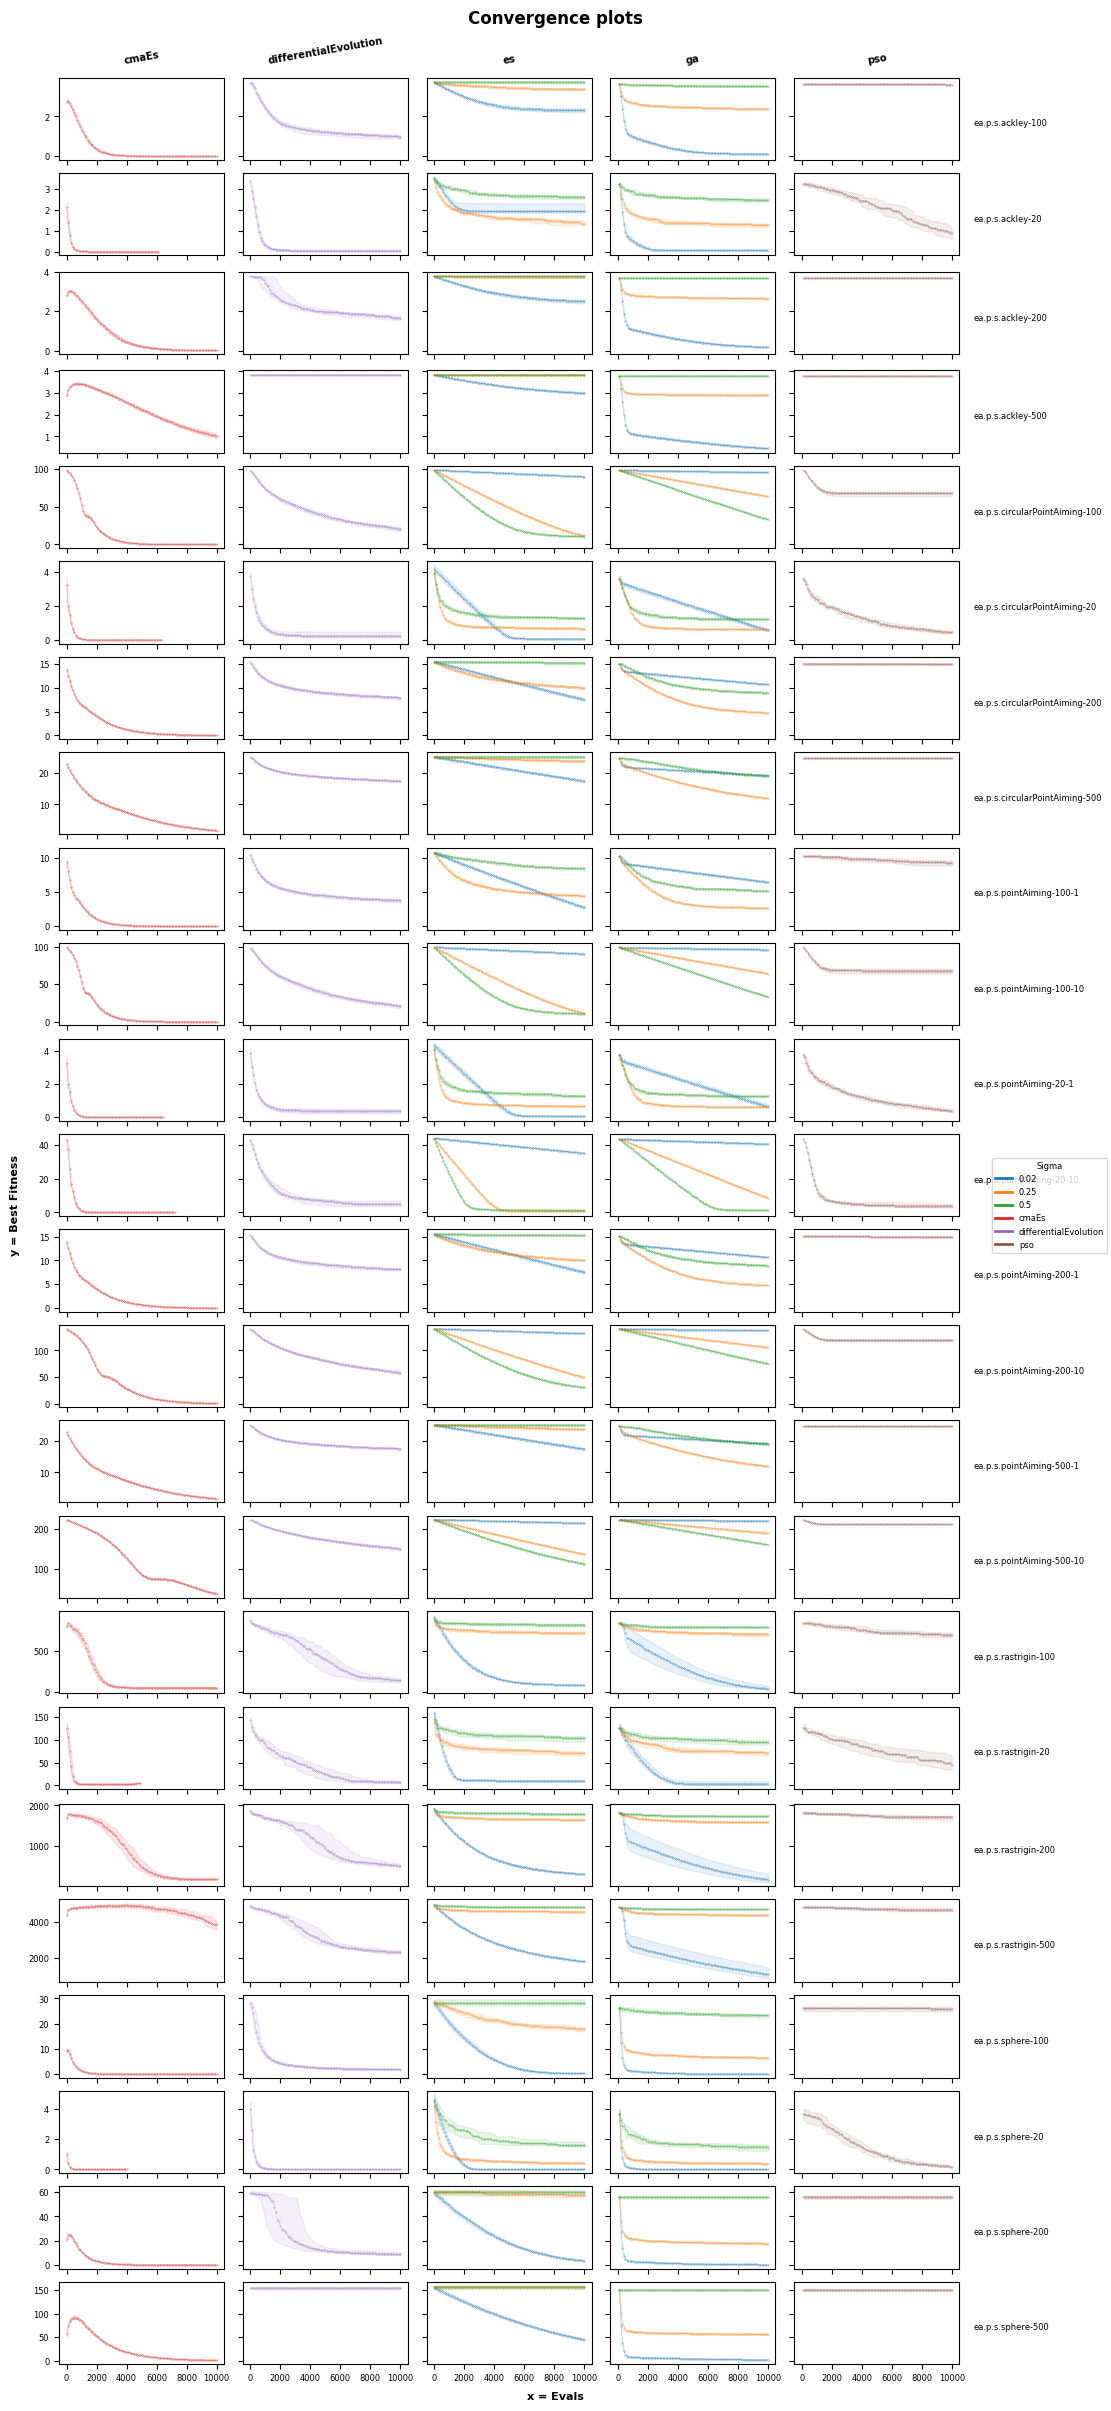

Saved → Figures/Scenario_1/Scenario_1_Convergence.png


In [6]:
fig, axs = plt.subplots(
    len(problems), len(solvers),
    sharex=True, sharey='row',
    layout='constrained',
    figsize=(2.2 * len(solvers), len(problems))
)
# Đảm bảo axs luôn là 2-D
if len(problems) == 1:
    axs = axs[np.newaxis, :]
if len(solvers) == 1:
    axs = axs[:, np.newaxis]

fig.suptitle('Convergence plots', fontsize=12, fontweight='bold')
fig.supxlabel('x = Evals', fontsize=8, fontweight='bold')
fig.supylabel('y = Best Fitness', fontsize=8, fontweight='bold')

for i, problem in enumerate(problems):
    axs[i, len(solvers)-1].yaxis.set_label_position('right')
    axs[i, len(solvers)-1].set_ylabel(
        problem, rotation='horizontal', labelpad=10, horizontalalignment='left')

    pre_pre = united_CSV[united_CSV['problem'] == problem]

    for j, solver in enumerate(solvers):
        axs[0, j].set_title(solver, pad=10, rotation=10, weight='bold')
        pre_filtered = pre_pre[pre_pre['solver'] == solver]

        for sigma_index, sigma in enumerate(sigmas):
            color = color_map.colors[sigma_index % len(color_map.colors)]
            filtered = pre_filtered[pre_filtered['sigma'] == sigma]
            if filtered.empty:
                continue

            grouped = (filtered
                       .groupby('evals_quantized')['best_fitness']
                       .describe()[['25%', '50%', '75%']])
            evals  = grouped.index * delta_quantization
            median = grouped['50%']
            q1, q3 = grouped['25%'], grouped['75%']

            axs[i, j].scatter(evals, median, marker='o', s=0.05,
                              color=color, label=sigma)
            axs[i, j].plot(evals, median, color=color)
            axs[i, j].fill_between(evals, q1, q3, color=color, alpha=0.1)

legend_elements = [
    Line2D([0], [0], color=color_map.colors[i % len(color_map.colors)],
           lw=2, label=s)
    for i, s in enumerate(sigmas)
]
legend = fig.legend(handles=legend_elements, loc='center right')
legend.set_title('Sigma')

out_path = f'Figures/{experiment_name}/{experiment_name}_Convergence.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved → {out_path}')

## 2. Effectiveness boxplots
Boxplot nằm ngang của best fitness tại lần đánh giá cuối cùng.

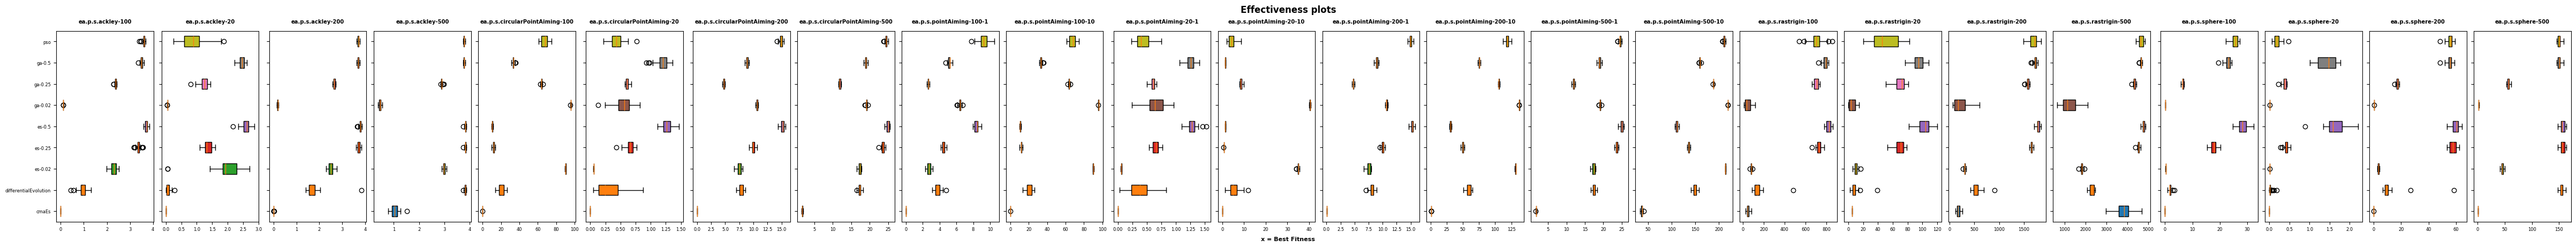

Saved → Figures/Scenario_1/Scenario_1_Effectiveness.png


In [7]:
# Lọc dòng cuối mỗi run
last_evals_df = united_CSV[
    united_CSV.groupby(['problem', 'solver_sigma_seed'])['evals']
              .transform('max') == united_CSV['evals']
].copy()

fig, axs = plt.subplots(
    1, len(problems),
    sharex=False, sharey=True,
    layout='constrained',
    figsize=(2 * len(problems), 0.5 * len(solvers_sigmas))
)
if len(problems) == 1:
    axs = [axs]

fig.suptitle('Effectiveness plots', fontsize=12, fontweight='bold')
fig.supxlabel('x = Best Fitness', fontsize=8, fontweight='bold')

for i, problem in enumerate(problems):
    axs[i].set_title(problem, pad=10, weight='bold')

    data_to_plot, labels = [], []
    pre_pre = united_CSV[united_CSV['problem'] == problem]

    for solver_sigma in solvers_sigmas:
        pre_filtered = pre_pre[pre_pre['solver_sigma'] == solver_sigma]
        if pre_filtered.empty:
            continue
        max_eval    = pre_filtered['evals'].max()
        filtered    = pre_filtered[pre_filtered['evals'] == max_eval]
        data_to_plot.append(filtered['best_fitness'].tolist())
        labels.append(solver_sigma)

    bp = axs[i].boxplot(data_to_plot, patch_artist=True, vert=False)

    # Lưu dữ liệu LaTeX
    try:
        df_latex = pd.DataFrame(
            list(map(list, zip(*data_to_plot))), columns=labels)
        df_latex.to_csv(
            f'LaTeX/{experiment_name}/{experiment_name}_EffectiveMatrix_{problem}.txt',
            sep='\t', index=False)
    except Exception:
        pass

    for patch, color in zip(bp['boxes'],
                            color_map.colors[:len(labels)]):
        patch.set_facecolor(color)

    axs[i].set_yticks(range(1, len(labels) + 1))
    axs[i].set_yticklabels(labels)

out_path = f'Figures/{experiment_name}/{experiment_name}_Effectiveness.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved → {out_path}')

## 3. Number of Victories Score (NoVS)
Wilcoxon test, α = 0.01, so sánh từng solver với solver tốt nhất (theo median).

In [8]:
binary_df = pd.DataFrame(index=problems, columns=solvers_sigmas)

for problem in problems:
    filtered  = last_evals_df[last_evals_df['problem'] == problem]
    objective = filtered['objective'].iloc[0]
    ascending = (objective == 'minimize')

    median_data    = (filtered.groupby('solver_sigma')['best_fitness']
                              .median()
                              .sort_values(ascending=ascending))
    best_ss        = median_data.index[0]
    best_vals      = filtered[filtered['solver_sigma'] == best_ss]['best_fitness']

    for ss in solvers_sigmas:
        if ss == best_ss:
            binary_df.at[problem, ss] = 1
            continue
        other_vals = filtered[filtered['solver_sigma'] == ss]['best_fitness']
        if other_vals.empty or len(other_vals) != len(best_vals):
            binary_df.at[problem, ss] = 0
            continue
        try:
            _, p = wilcoxon(best_vals.values, other_vals.values)
            binary_df.at[problem, ss] = 1 if p > level_significance else 0
        except Exception:
            binary_df.at[problem, ss] = 0

novs = binary_df.sum().rename('NOVS')
result_df = pd.concat([binary_df, novs.to_frame().T])

result_df.to_excel(
    f'XLSX Files/{experiment_name}/{experiment_name}_NOVS.xlsx')

print('NoVS (sorted):\n')
print(result_df.loc['NOVS'].astype(int).sort_values(ascending=False).to_string())

NoVS (sorted):

cmaEs                    22
ga-0.02                   5
es-0.02                   1
es-0.25                   0
differentialEvolution     0
es-0.5                    0
ga-0.25                   0
ga-0.5                    0
pso                       0


## 4. Normalized Effectiveness Ranking (NER) boxplot

C:\Users\ACER\AppData\Local\Temp\ipykernel_14796\3178148119.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(ss_rankings, patch_artist=True,


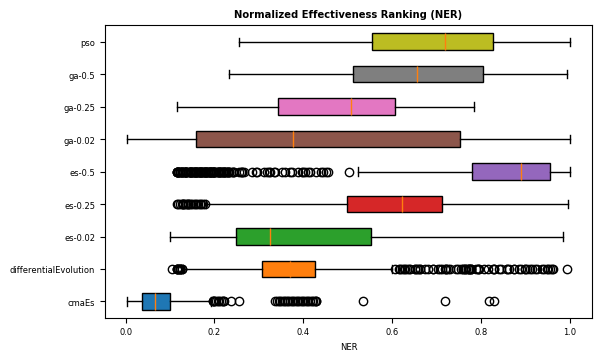

Saved → Figures/Scenario_1/Scenario_1_NER.png


In [9]:
normalization_factor    = len(solvers_sigmas) * len(seeds)
ss_rankings             = [[] for _ in solvers_sigmas]

for problem in problems:
    filtered  = last_evals_df[last_evals_df['problem'] == problem]
    ascending = (filtered['objective'].iloc[0] == 'minimize')
    sorted_d  = filtered.sort_values('best_fitness', ascending=ascending)

    for j, row in enumerate(sorted_d.itertuples()):
        ss    = row.solver_sigma
        idx   = solvers_sigmas.index(ss)
        ss_rankings[idx].append((j + 1) / normalization_factor)

plt.figure(figsize=(6, 0.4 * len(solvers_sigmas)))
bp = plt.boxplot(ss_rankings, patch_artist=True,
                 vert=False, labels=solvers_sigmas)
for patch, color in zip(bp['boxes'],
                        color_map.colors[:len(solvers_sigmas)]):
    patch.set_facecolor(color)
plt.title('Normalized Effectiveness Ranking (NER)', fontweight='bold')
plt.xlabel('NER')
plt.tight_layout()

# Lưu dữ liệu LaTeX
try:
    df_ner = pd.DataFrame(
        list(map(list, zip(*ss_rankings))), columns=solvers_sigmas)
    df_ner.to_csv(
        f'LaTeX/{experiment_name}/AAA_{experiment_name}_NER.txt',
        sep='\t', index=False)
except Exception:
    pass

out_path = f'Figures/{experiment_name}/{experiment_name}_NER.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved → {out_path}')

## 5. Efficiency boxplot (EtTQ — Evals to 3rd Quartile)

C:\Users\ACER\AppData\Local\Temp\ipykernel_14796\2866511173.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(ss_first_eval, patch_artist=True,


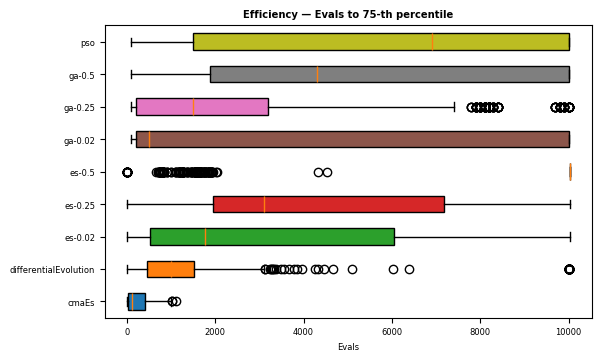

Saved → Figures/Scenario_1/Scenario_1_Efficiency_percentile-0.75.png


In [10]:
ss_first_eval = [[] for _ in solvers_sigmas]

for problem in problems:
    last_prob = last_evals_df[last_evals_df['problem'] == problem].copy()
    objective = last_prob['objective'].iloc[0]
    ascending = (objective == 'minimize')

    sorted_last = last_prob.sort_values('best_fitness', ascending=ascending)
    perc_idx    = int(efficiency_percentile_reference * len(sorted_last))
    threshold   = sorted_last.iloc[min(perc_idx, len(sorted_last)-1)]['best_fitness']

    prob_data = united_CSV[united_CSV['problem'] == problem]

    for ss in solvers_sigmas:
        idx       = solvers_sigmas.index(ss)
        ss_data   = prob_data[prob_data['solver_sigma'] == ss]

        for seed in seeds:
            run = ss_data[ss_data['seed'] == seed].sort_values('evals')
            if run.empty:
                continue

            # Tìm lần đánh giá đầu tiên vượt threshold
            hit = run[
                run['best_fitness'] <= threshold
                if ascending
                else run['best_fitness'] >= threshold
            ]
            if hit.empty:
                # Không đạt → gán bằng ngân sách tối đa
                ss_first_eval[idx].append(int(run['evals'].max()))
            else:
                ss_first_eval[idx].append(int(hit.iloc[0]['evals']))

plt.figure(figsize=(6, 0.4 * len(solvers_sigmas)))
bp = plt.boxplot(ss_first_eval, patch_artist=True,
                 vert=False, labels=solvers_sigmas)
for patch, color in zip(bp['boxes'],
                        color_map.colors[:len(solvers_sigmas)]):
    patch.set_facecolor(color)
plt.title(
    f'Efficiency — Evals to {int(efficiency_percentile_reference*100)}-th percentile',
    fontweight='bold')
plt.xlabel('Evals')
plt.tight_layout()

# Lưu dữ liệu LaTeX
try:
    df_eff = pd.DataFrame(
        list(map(list, zip(*ss_first_eval))), columns=solvers_sigmas)
    df_eff.to_csv(
        f'LaTeX/{experiment_name}/AAA_{experiment_name}_Efficiency_percentile-{efficiency_percentile_reference}.txt',
        sep='\t', index=False)
except Exception:
    pass

out_path = (f'Figures/{experiment_name}/{experiment_name}'
            f'_Efficiency_percentile-{efficiency_percentile_reference}.png')
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved → {out_path}')

## 6. Mean NER vs. p (genotype size)

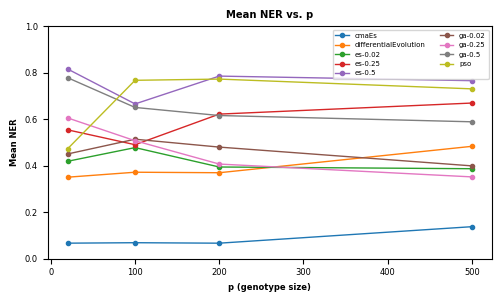

Saved → Figures/Scenario_1/Scenario_1_meanNER-vs-p.png


In [11]:
mean_NER = pd.DataFrame(index=problems, columns=solvers_sigmas, dtype=float)
genotype_size_series = last_evals_df.groupby('problem')['genotype_size'].first()
mean_NERs = pd.concat([genotype_size_series, mean_NER], axis=1)

for problem in problems:
    filtered  = last_evals_df[last_evals_df['problem'] == problem]
    ascending = (filtered['objective'].iloc[0] == 'minimize')
    sorted_d  = filtered.sort_values('best_fitness', ascending=ascending)

    ss_rank_local = [[] for _ in solvers_sigmas]
    for j, row in enumerate(sorted_d.itertuples()):
        idx = solvers_sigmas.index(row.solver_sigma)
        ss_rank_local[idx].append(j + 1)

    for k, ss in enumerate(solvers_sigmas):
        if ss_rank_local[k]:
            mean_rank      = statistics.mean(ss_rank_local[k])
            norm_mean_rank = mean_rank / (len(solvers_sigmas) * len(seeds))
            mean_NERs.loc[problem, ss] = norm_mean_rank

mean_NERs.to_excel(
    f'XLSX Files/{experiment_name}/{experiment_name}_meanNER-vs-p.xlsx')

mean_NERs_sorted  = mean_NERs.sort_values('genotype_size')
mean_NERs_grouped = (mean_NERs_sorted
                     .groupby('genotype_size')[solvers_sigmas]
                     .mean()
                     .reset_index())
mean_NERs_grouped.to_csv(
    f'LaTeX/{experiment_name}/AAA_{experiment_name}_meanNER-vs-p.txt',
    sep='\t', index=False)

# ── Vẽ ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
p_vals  = mean_NERs_grouped['genotype_size'].astype(float)

for k, ss in enumerate(solvers_sigmas):
    color = color_map.colors[k % len(color_map.colors)]
    ner_vals = mean_NERs_grouped[ss].astype(float)
    ax.plot(p_vals, ner_vals, marker='o', markersize=3,
            linewidth=1, color=color, label=ss)

ax.set_xlabel('p (genotype size)', fontweight='bold')
ax.set_ylabel('Mean NER', fontweight='bold')
ax.set_title('Mean NER vs. p', fontweight='bold')
ax.legend(loc='upper right', fontsize=5, ncol=2)
ax.set_ylim(0, 1)
plt.tight_layout()

out_path = f'Figures/{experiment_name}/{experiment_name}_meanNER-vs-p.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved → {out_path}')

---
**Tóm tắt output:**
```
Figures/Scenario_1/
  ├── Scenario_1_Convergence.png
  ├── Scenario_1_Effectiveness.png
  ├── Scenario_1_NER.png
  ├── Scenario_1_Efficiency_percentile-0.75.png
  └── Scenario_1_meanNER-vs-p.png
XLSX Files/Scenario_1/
  ├── Scenario_1_NOVS.xlsx
  └── Scenario_1_meanNER-vs-p.xlsx
LaTeX/Scenario_1/
  ├── Scenario_1_EffectiveMatrix_<problem>.txt  (mỗi problem 1 file)
  ├── AAA_Scenario_1_NER.txt
  ├── AAA_Scenario_1_Efficiency_percentile-0.75.txt
  └── AAA_Scenario_1_meanNER-vs-p.txt
```